# PCA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
class Custom_PCA:
    """
    PCA tự hiện thực theo công thức toán học, chỉ dùng NumPy.
        1. Căn giữa dữ liệu:      Xc = X - mean
        2. Ma trận hiệp biến:     C  = (Xc^T @ Xc) / (n - 1)
        3. Trị riêng / vectơ riêng của C
        4. Sắp xếp trị riêng giảm dần, lấy k vectơ riêng đầu -> W
        5. Chiếu dữ liệu:         Z  = Xc @ W
    """

    def __init__(self, n_components):
        self.n_components = n_components
        self.mean_ = None
        self.components_ = None            # W: (n_features, k)
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None

    def fit(self, X):
        X = np.asarray(X, dtype=np.float64)

        # 1. Căn giữa dữ liệu theo mean của tập train
        self.mean_ = np.mean(X, axis=0)
        Xc = X - self.mean_

        # 2. Ma trận hiệp biến
        n_samples = Xc.shape[0]
        cov_matrix = (Xc.T @ Xc) / (n_samples - 1)

        # 3. Trị riêng & vectơ riêng (eigh cho ma trận đối xứng -> kết quả thực)
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        # 4. Sắp xếp giảm dần theo trị riêng
        sorted_idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[sorted_idx]
        eigenvectors = eigenvectors[:, sorted_idx]

        # 5. Lưu k thành phần chính đầu tiên
        k = self.n_components
        self.components_ = eigenvectors[:, :k]
        self.explained_variance_ = eigenvalues[:k]

        total_var = np.sum(eigenvalues)
        self.explained_variance_ratio_ = self.explained_variance_ / total_var
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=np.float64)
        return (X - self.mean_) @ self.components_

    def fit_transform(self, X):
        return self.fit(X).transform(X)

In [3]:
class Custom_LDA:
    """
    LDA (Fisher) tự hiện thực theo công thức toán học, chỉ dùng NumPy.
        1. mean tổng thể và mean từng lớp
        2. S_W = sum_c (X_c - m_c)^T (X_c - m_c)          (within-class scatter)
        3. S_B = sum_c n_c (m_c - m)(m_c - m)^T           (between-class scatter)
        4. Trị riêng / vectơ riêng của pinv(S_W) @ S_B
        5. Sắp xếp trị riêng giảm dần, lấy k vectơ riêng đầu -> W
        6. Chiếu dữ liệu: Z = X @ W      (k <= n_classes - 1)
    """

    def __init__(self, n_components):
        self.n_components = n_components
        self.classes_ = None
        self.components_ = None            # W: (n_features, k)
        self.eigenvalues_ = None

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y)

        n_features = X.shape[1]
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)

        # LDA chỉ tách được tối đa (số class - 1) chiều
        k = min(self.n_components, n_classes - 1, n_features)
        self.n_components = k

        # 1. Mean tổng thể & mean từng lớp
        mean_overall = np.mean(X, axis=0)

        # 2. Within-class scatter S_W
        S_W = np.zeros((n_features, n_features))
        mean_vectors = {}
        for c in self.classes_:
            X_c = X[y == c]
            m_c = np.mean(X_c, axis=0)
            mean_vectors[c] = m_c
            diff = X_c - m_c
            S_W += diff.T @ diff

        # 3. Between-class scatter S_B
        S_B = np.zeros((n_features, n_features))
        for c in self.classes_:
            n_c = X[y == c].shape[0]
            mean_diff = (mean_vectors[c] - mean_overall).reshape(-1, 1)
            S_B += n_c * (mean_diff @ mean_diff.T)

        # 4. Trị riêng của pinv(S_W) @ S_B  (pinv để tránh S_W suy biến)
        eigenvalues, eigenvectors = np.linalg.eig(np.linalg.pinv(S_W) @ S_B)
        eigenvalues = np.real(eigenvalues)
        eigenvectors = np.real(eigenvectors)

        # 5. Sắp xếp giảm dần, lấy k vectơ riêng đầu
        sorted_idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[sorted_idx]
        eigenvectors = eigenvectors[:, sorted_idx]

        self.components_ = eigenvectors[:, :k]
        self.eigenvalues_ = eigenvalues[:k]

        # Chuẩn hóa độ dài vectơ chiếu cho ổn định số học
        norms = np.linalg.norm(self.components_, axis=0)
        norms[norms == 0] = 1.0
        self.components_ = self.components_ / norms
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=np.float64)
        return X @ self.components_

    def fit_transform(self, X, y):
        return self.fit(X, y).transform(X)

In [4]:
def apply_pca(X_train, X_test, n_components, verbose=True):
    """
    Giảm chiều bằng Custom_PCA (thủ công).
    Trả về: (X_train_pca, X_test_pca) — dữ liệu sau giảm chiều.
    """
    dim_in = np.asarray(X_train).shape[1]

    pca = Custom_PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    if verbose:
        print(f"[PCA] số chiều: {dim_in} -> {X_train_pca.shape[1]}")
        print(f"      X_train: {np.asarray(X_train).shape} -> {X_train_pca.shape}")
        print(f"      X_test : {np.asarray(X_test).shape} -> {X_test_pca.shape}")
        print(f"      Phương sai giữ lại: {pca.explained_variance_ratio_.sum():.4f}")

    return X_train_pca, X_test_pca

In [5]:
def apply_lda(X_train, X_test, y_train, n_components, verbose=True):
    """
    Giảm chiều bằng Custom_LDA (thủ công).
    Đầu vào có thể là dữ liệu gốc HOẶC dữ liệu đã qua apply_pca.
    Trả về: (X_train_lda, X_test_lda) — dữ liệu sau giảm chiều.
    """
    dim_in = np.asarray(X_train).shape[1]
    n_classes = len(np.unique(np.asarray(y_train)))

    lda = Custom_LDA(n_components=n_components)
    X_train_lda = lda.fit_transform(X_train, y_train)
    X_test_lda = lda.transform(X_test)

    if verbose:
        if lda.n_components < n_components:
            print(f"[LDA] n_components={n_components} vượt giới hạn "
                  f"(số class - 1 = {n_classes - 1}) -> dùng {lda.n_components}")
        print(f"[LDA] số chiều: {dim_in} -> {X_train_lda.shape[1]} (số class = {n_classes})")
        print(f"      X_train: {np.asarray(X_train).shape} -> {X_train_lda.shape}")
        print(f"      X_test : {np.asarray(X_test).shape} -> {X_test_lda.shape}")

    return X_train_lda, X_test_lda

In [6]:
def pca_lda_knn(X, y,
                n_component_pca=57,
                n_component_lda=9,
                n_neighbors=5,
                test_size=0.3,
                random_state=42,
                verbose=True):
    """
    Pipeline: dữ liệu -> apply_pca (hàm 1) -> apply_lda (hàm 2) -> KNN.
    Ngoài ra tính thêm accuracy của model NORMAL: KNN trên dữ liệu chỉ chuẩn hóa
    (KHÔNG dùng PCA + LDA) để so sánh.
    Trả về dict: {"pca_lda": ..., "normal": ..., "delta": pca_lda - normal}
    """
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y)

    if verbose:
        print(f"Dữ liệu ban đầu : {X.shape} | số class: {len(np.unique(y))}")

    # Bước 0: chia train/test + chuẩn hóa
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # Bước 1: giảm chiều lần 1 — PCA
    X_tr_pca, X_te_pca = apply_pca(X_train_s, X_test_s,
                                   n_components=n_component_pca, verbose=verbose)

    # Bước 2: giảm chiều lần 2 — LDA trên output của PCA
    X_tr_lda, X_te_lda = apply_lda(X_tr_pca, X_te_pca, y_train,
                                   n_components=n_component_lda, verbose=verbose)

    # Bước 3: phân loại KNN trên dữ liệu đã giảm chiều (PCA -> LDA)
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(X_tr_lda, y_train)
    acc = accuracy_score(y_test, knn.predict(X_te_lda))

    # Bước 4: model NORMAL — KNN trên dữ liệu gốc đã chuẩn hóa (không PCA + LDA)
    knn_normal = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn_normal.fit(X_train_s, y_train)
    acc_normal = accuracy_score(y_test, knn_normal.predict(X_test_s))

    if verbose:
        print(f"[KNN k={n_neighbors}] Accuracy (PCA -> LDA -> KNN)      : {acc:.4f}")
        print(f"[KNN k={n_neighbors}] Accuracy (NORMAL): {acc_normal:.4f}")
        print(f"  -> Delta (PCA->LDA - normal): {acc - acc_normal:+.4f} "
              f"| số chiều: {X_train_s.shape[1]} -> {X_tr_lda.shape[1]}")

    return {"pca_lda": acc, "normal": acc_normal, "delta": acc - acc_normal}

In [7]:
from sklearn.datasets import load_breast_cancer, fetch_lfw_people, fetch_openml

print("=" * 60, "\nBREAST CANCER")
data = load_breast_cancer()
res_cancer = pca_lda_knn(data.data, data.target,
                         n_component_pca=8, n_component_lda=1)

print("=" * 60, "\nLFW PEOPLE")
lfw = fetch_lfw_people(min_faces_per_person=20, resize=0.4)
res_lfw = pca_lda_knn(lfw.data, lfw.target,
                      n_component_pca=100, n_component_lda=61)

print("=" * 60, "\nMNIST")
mnist = fetch_openml('mnist_784', version=1, parser='auto', as_frame=False)
res_mnist = pca_lda_knn(mnist.data, mnist.target.astype('int64'),
                        n_component_pca=57, n_component_lda=9)

print("\n" + "=" * 60)
print(f"{'Dataset':<15} {'PCA->LDA->KNN':>14} {'NORMAL (KNN)':>14} {'Delta':>9}")
for name, res in [("Breast Cancer", res_cancer), ("LFW People", res_lfw), ("MNIST", res_mnist)]:
    print(f"{name:<15} {res['pca_lda']:>14.4f} {res['normal']:>14.4f} {res['delta']:>+9.4f}")

BREAST CANCER
Dữ liệu ban đầu : (569, 30) | số class: 2
[PCA] số chiều: 30 -> 8
      X_train: (398, 30) -> (398, 8)
      X_test : (171, 30) -> (171, 8)
      Phương sai giữ lại: 0.9264
[LDA] số chiều: 8 -> 1 (số class = 2)
      X_train: (398, 8) -> (398, 1)
      X_test : (171, 8) -> (171, 1)
[KNN k=5] Accuracy (PCA -> LDA -> KNN)      : 0.9825
[KNN k=5] Accuracy (NORMAL): 0.9591
  -> Delta (PCA->LDA - normal): +0.0234 | số chiều: 30 -> 1
LFW PEOPLE
Dữ liệu ban đầu : (3023, 1850) | số class: 62
[PCA] số chiều: 1850 -> 100
      X_train: (2116, 1850) -> (2116, 100)
      X_test : (907, 1850) -> (907, 100)
      Phương sai giữ lại: 0.9064
[LDA] số chiều: 100 -> 61 (số class = 62)
      X_train: (2116, 100) -> (2116, 61)
      X_test : (907, 100) -> (907, 61)
[KNN k=5] Accuracy (PCA -> LDA -> KNN)      : 0.5050
[KNN k=5] Accuracy (NORMAL): 0.2944
  -> Delta (PCA->LDA - normal): +0.2106 | số chiều: 1850 -> 61
MNIST
Dữ liệu ban đầu : (70000, 784) | số class: 10
[PCA] số chiều: 784 -> 57


# Metrics (precision, recall, f1 score)

In [8]:
METRIC_NAMES = ["precision", "recall", "f1"]


def _knn_metrics(X_tr, y_tr, X_te, y_te, n_neighbors=5, average="macro"):
    """Train KNN rồi trả về dict precision / recall / f1."""
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(X_tr, y_tr)
    y_pred = knn.predict(X_te)
    return {
        "precision": precision_score(y_te, y_pred, average=average, zero_division=0),
        "recall":    recall_score(y_te, y_pred, average=average, zero_division=0),
        "f1":        f1_score(y_te, y_pred, average=average, zero_division=0),
    }


def plot_delta_heatmap(df_delta, dataset_name="dataset"):
    """Heatmap delta: PCA->LDA so với từng biến thể (dương = PCA->LDA tốt hơn)."""
    vmax = np.abs(df_delta.values).max()
    vmax = 0.01 if vmax == 0 else vmax

    plt.figure(figsize=(7.5, 3.4))
    sns.heatmap(df_delta, annot=True, fmt="+.4f", cmap="RdBu_r",
                center=0, vmin=-vmax, vmax=vmax, linewidths=0.5,
                cbar_kws={"label": "delta (PCA->LDA - biến thể)"})
    plt.title(f"Delta metric của PCA->LDA->KNN | {dataset_name}\n"
              f"(đỏ = PCA->LDA tốt hơn, xanh = tệ hơn)")
    plt.xlabel("Metric")
    plt.ylabel("So với")
    plt.tight_layout()
    plt.show()


def pca_lda_knn(X, y,
                n_component_pca=57,
                n_component_lda=9,
                n_neighbors=5,
                test_size=0.3,
                random_state=42,
                average="macro",
                dataset_name="dataset",
                plot_heatmap=True,
                verbose=True):
    """
    Pipeline chính: dữ liệu -> apply_pca (hàm 1) -> apply_lda (hàm 2) -> KNN.
    Kết quả metric chính chỉ lấy của PCA -> LDA.
    Ngoài ra tính thêm 3 biến thể để so sánh delta:
        - không dùng PCA        (chỉ LDA)
        - không dùng LDA        (chỉ PCA)
        - không dùng PCA + LDA  (dữ liệu gốc đã chuẩn hóa)
    """
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y)

    if verbose:
        print(f"Dữ liệu ban đầu : {X.shape} | số class: {len(np.unique(y))}")

    # Bước 0: chia train/test + chuẩn hóa
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # ============ PIPELINE CHÍNH: PCA -> LDA -> KNN ============
    X_tr_pca, X_te_pca = apply_pca(X_train_s, X_test_s,
                                   n_components=n_component_pca, verbose=verbose)
    X_tr_pl, X_te_pl = apply_lda(X_tr_pca, X_te_pca, y_train,
                                 n_components=n_component_lda, verbose=verbose)
    main = _knn_metrics(X_tr_pl, y_train, X_te_pl, y_test, n_neighbors, average)

    if verbose:
        print(f"[KNN k={n_neighbors}] PCA -> LDA -> KNN  (average='{average}')")
        for name in METRIC_NAMES:
            print(f"      {name:<10}: {main[name]:.4f}")

    # ============ CÁC BIẾN THỂ CHỈ DÙNG ĐỂ TÍNH DELTA ============
    # 1. Không dùng PCA -> chỉ LDA trên dữ liệu gốc
    X_tr_l, X_te_l = apply_lda(X_train_s, X_test_s, y_train,
                               n_components=n_component_lda, verbose=False)
    no_pca = _knn_metrics(X_tr_l, y_train, X_te_l, y_test, n_neighbors, average)

    # 2. Không dùng LDA -> chỉ PCA
    no_lda = _knn_metrics(X_tr_pca, y_train, X_te_pca, y_test, n_neighbors, average)

    # 3. Không dùng PCA + LDA -> dữ liệu gốc đã chuẩn hóa
    no_both = _knn_metrics(X_train_s, y_train, X_test_s, y_test, n_neighbors, average)

   # ============ GOM 4 CẤU HÌNH ============
    all_results = {
        "normal":  no_both,   # không PCA, không LDA
        "pca":     no_lda,    # chỉ PCA
        "lda":     no_pca,    # chỉ LDA
        "pca_lda": main,      # PCA -> LDA (pipeline chính)
    }

    # ============ BẢNG DELTA (pca_lda trừ từng cấu hình còn lại) ============
    rows = {
        "vs normal (không PCA + LDA)": no_both,
        "vs pca (không LDA)":          no_lda,
        "vs lda (không PCA)":          no_pca,
    }
    df_delta = pd.DataFrame(
        {m: {label: main[m] - vals[m] for label, vals in rows.items()} for m in METRIC_NAMES}
    )[METRIC_NAMES]

    if verbose:
        print("\n--- DELTA (pca_lda trừ cấu hình khác) ---")
        print(df_delta.round(4))

    if plot_heatmap:
        plot_delta_heatmap(df_delta, dataset_name=dataset_name)

    return {"metrics": main, "all": all_results, "delta": df_delta}

BREAST CANCER
Dữ liệu ban đầu : (569, 30) | số class: 2
[PCA] số chiều: 30 -> 8
      X_train: (398, 30) -> (398, 8)
      X_test : (171, 30) -> (171, 8)
      Phương sai giữ lại: 0.9264
[LDA] số chiều: 8 -> 1 (số class = 2)
      X_train: (398, 8) -> (398, 1)
      X_test : (171, 8) -> (171, 1)
[KNN k=5] PCA -> LDA -> KNN  (average='macro')
      precision : 0.9797
      recall    : 0.9828
      f1        : 0.9812

--- DELTA (pca_lda trừ cấu hình khác) ---
                             precision  recall      f1
vs normal (không PCA + LDA)     0.0222  0.0284  0.0253
vs pca (không LDA)              0.0143  0.0238  0.0192
vs lda (không PCA)              0.0341  0.0265  0.0308


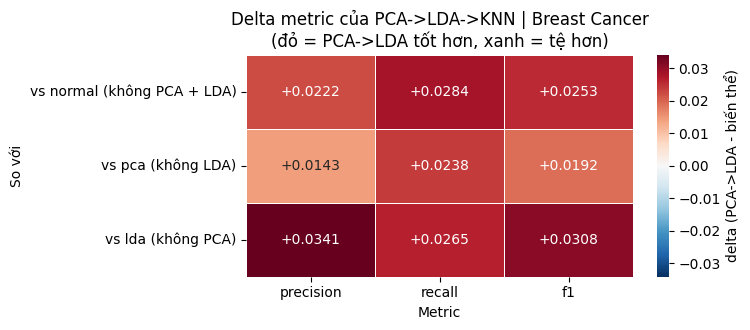


--- METRIC (Breast Cancer) ---
         precision  recall      f1
normal      0.9575  0.9544  0.9559
pca         0.9654  0.9590  0.9620
lda         0.9456  0.9563  0.9504
pca_lda     0.9797  0.9828  0.9812
LFW PEOPLE
Dữ liệu ban đầu : (3023, 1850) | số class: 62
[PCA] số chiều: 1850 -> 100
      X_train: (2116, 1850) -> (2116, 100)
      X_test : (907, 1850) -> (907, 100)
      Phương sai giữ lại: 0.9064
[LDA] số chiều: 100 -> 61 (số class = 62)
      X_train: (2116, 100) -> (2116, 61)
      X_test : (907, 100) -> (907, 61)
[KNN k=5] PCA -> LDA -> KNN  (average='macro')
      precision : 0.5788
      recall    : 0.3812
      f1        : 0.4194

--- DELTA (pca_lda trừ cấu hình khác) ---
                             precision  recall      f1
vs normal (không PCA + LDA)     0.2757  0.2282  0.2494
vs pca (không LDA)              0.2594  0.2066  0.2283
vs lda (không PCA)              0.5149  0.3206  0.3608


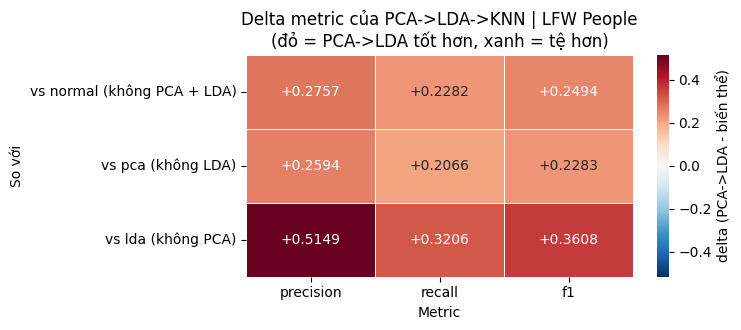


--- METRIC (LFW People) ---
         precision  recall      f1
normal      0.3031  0.1531  0.1700
pca         0.3194  0.1747  0.1911
lda         0.0639  0.0606  0.0586
pca_lda     0.5788  0.3812  0.4194
MNIST
Dữ liệu ban đầu : (70000, 784) | số class: 10
[PCA] số chiều: 784 -> 57
      X_train: (49000, 784) -> (49000, 57)
      X_test : (21000, 784) -> (21000, 57)
      Phương sai giữ lại: 0.5818
[LDA] số chiều: 57 -> 9 (số class = 10)
      X_train: (49000, 57) -> (49000, 9)
      X_test : (21000, 57) -> (21000, 9)
[KNN k=5] PCA -> LDA -> KNN  (average='macro')
      precision : 0.9161
      recall    : 0.9159
      f1        : 0.9157

--- DELTA (pca_lda trừ cấu hình khác) ---
                             precision  recall      f1
vs normal (không PCA + LDA)    -0.0273 -0.0262 -0.0267
vs pca (không LDA)             -0.0427 -0.0425 -0.0428
vs lda (không PCA)              0.0044  0.0046  0.0046


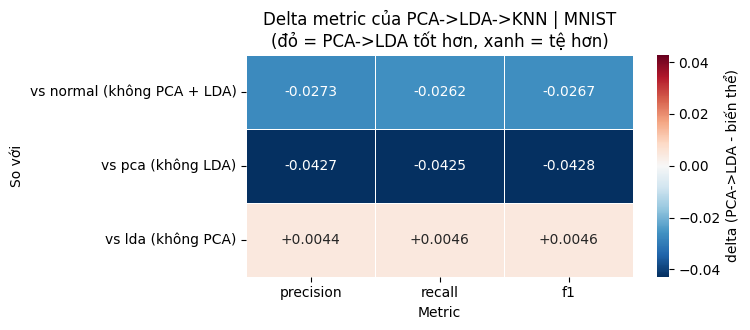


--- METRIC (MNIST) ---
         precision  recall      f1
normal      0.9433  0.9421  0.9425
pca         0.9587  0.9585  0.9586
lda         0.9117  0.9113  0.9112
pca_lda     0.9161  0.9159  0.9157

TỔNG HỢP TẤT CẢ
                       precision  recall      f1
dataset       config                            
Breast Cancer normal      0.9575  0.9544  0.9559
              pca         0.9654  0.9590  0.9620
              lda         0.9456  0.9563  0.9504
              pca_lda     0.9797  0.9828  0.9812
LFW People    normal      0.3031  0.1531  0.1700
              pca         0.3194  0.1747  0.1911
              lda         0.0639  0.0606  0.0586
              pca_lda     0.5788  0.3812  0.4194
MNIST         normal      0.9433  0.9421  0.9425
              pca         0.9587  0.9585  0.9586
              lda         0.9117  0.9113  0.9112
              pca_lda     0.9161  0.9159  0.9157


In [9]:
from sklearn.datasets import load_breast_cancer, fetch_lfw_people, fetch_openml

CONFIG_ORDER = ["normal", "pca", "lda", "pca_lda"]


def show_table(res, dataset_name):
    df = pd.DataFrame(res["all"]).T.loc[CONFIG_ORDER, METRIC_NAMES]
    print(f"\n--- METRIC ({dataset_name}) ---")
    print(df.round(4))
    return df


print("=" * 60, "\nBREAST CANCER")
data = load_breast_cancer()
res_cancer = pca_lda_knn(data.data, data.target,
                         n_component_pca=8, n_component_lda=1,
                         dataset_name="Breast Cancer")
df_cancer = show_table(res_cancer, "Breast Cancer")

print("=" * 60, "\nLFW PEOPLE")
lfw = fetch_lfw_people(min_faces_per_person=20, resize=0.4)
res_lfw = pca_lda_knn(lfw.data, lfw.target,
                      n_component_pca=100, n_component_lda=61,
                      dataset_name="LFW People")
df_lfw = show_table(res_lfw, "LFW People")

print("=" * 60, "\nMNIST")
mnist = fetch_openml('mnist_784', version=1, parser='auto', as_frame=False)
res_mnist = pca_lda_knn(mnist.data, mnist.target.astype('int64'),
                        n_component_pca=57, n_component_lda=9,
                        dataset_name="MNIST")
df_mnist = show_table(res_mnist, "MNIST")

# --- Bảng tổng hợp cả 3 bộ dữ liệu x 4 cấu hình ---
df_summary = pd.concat(
    {"Breast Cancer": df_cancer, "LFW People": df_lfw, "MNIST": df_mnist},
    names=["dataset", "config"]
)
print("\n" + "=" * 60)
print("TỔNG HỢP TẤT CẢ")
print(df_summary.round(4))